# Employee Attrition Prediction using Machine Learning

This project aims to predict whether an employee is likely to leave the organization using machine learning techniques.

Two supervised learning algorithms are used:

- Logistic Regression
- Decision Tree Classifier

The model analyzes employee-related factors such as job satisfaction, work-life balance, overtime, salary, and years at the company to determine the likelihood of attrition.

## Introduction

Employee attrition is a major challenge for organizations. Losing skilled employees leads to additional costs related to recruitment, training, and productivity loss.

With the availability of HR analytics, machine learning can help organizations predict employee attrition based on historical employee data.

In this project, we build predictive models using Logistic Regression and Decision Tree Classifier to classify employees into two categories:

- Attrition = Yes (Employee likely to leave)
- Attrition = No (Employee likely to stay)

These models help HR teams identify high-risk employees and take preventive actions.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [3]:
df = pd.read_csv("employee_attrition.csv")

df.head()

,Age,Gender,Salary,JobRole,JobSatisfaction,WorkLifeBalance,YearsAtCompany,Overtime,DistanceFromHome,EducationLevel,PerformanceRating,MaritalStatus,Attrition
0,50,Male,113442,HR,1,4,18,Yes,15,1,3,Married,Yes
1,36,Male,87559,Sales,3,1,13,No,27,4,2,Single,No
2,29,Female,79205,Sales,4,3,23,No,16,5,4,Married,No
3,42,Female,93475,Technician,2,2,10,No,36,3,3,Married,Yes
4,40,Male,89341,HR,5,2,23,No,38,2,3,Divorced,No


In [4]:
df.shape

(4000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                4000 non-null   int64 
 1   Gender             4000 non-null   object
 2   Salary             4000 non-null   int64 
 3   JobRole            4000 non-null   object
 4   JobSatisfaction    4000 non-null   int64 
 5   WorkLifeBalance    4000 non-null   int64 
 6   YearsAtCompany     4000 non-null   int64 
 7   Overtime           4000 non-null   object
 8   DistanceFromHome   4000 non-null   int64 
 9   EducationLevel     4000 non-null   int64 
 10  PerformanceRating  4000 non-null   int64 
 11  MaritalStatus      4000 non-null   object
 12  Attrition          4000 non-null   object
dtypes: int64(8), object(5)
memory usage: 406.4+ KB


In [6]:
df.describe()

,Age,Salary,JobSatisfaction,WorkLifeBalance,YearsAtCompany,DistanceFromHome,EducationLevel,PerformanceRating
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,40.735500,72303.323500,2.985750,2.494000,14.431750,20.183750,3.029500,2.501250
std,10.998831,27639.883881,1.419877,1.117487,8.624409,11.239086,1.411073,1.119514
min,22.000000,25002.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,47982.000000,2.000000,2.000000,7.000000,11.000000,2.000000,2.000000
50%,41.000000,72035.500000,3.000000,2.000000,15.000000,20.000000,3.000000,2.000000
75%,50.000000,96478.500000,4.000000,3.000000,22.000000,30.000000,4.000000,4.000000
max,59.000000,119979.000000,5.000000,4.000000,29.000000,39.000000,5.000000,4.000000


In [7]:
df.isnull().sum()

Age                  0
Gender               0
Salary               0
JobRole              0
JobSatisfaction      0
WorkLifeBalance      0
YearsAtCompany       0
Overtime             0
DistanceFromHome     0
EducationLevel       0
PerformanceRating    0
MaritalStatus        0
Attrition            0
dtype: int64

## Dataset Description

The dataset contains employee information used to predict attrition.

### Target Variable
- Attrition (Yes / No)

### Predictor Variables
- Age
- Gender
- Salary
- JobRole
- JobSatisfaction
- WorkLifeBalance
- YearsAtCompany
- Overtime
- DistanceFromHome
- EducationLevel
- PerformanceRating
- MaritalStatus

The dataset contains approximately 4000 employee records.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of data and identify patterns.

The following analysis is performed:

- Checking dataset structure
- Checking missing values
- Visualizing attrition distribution
- Analyzing the relationship between job satisfaction and attrition
- Analyzing the relationship between work-life balance and attrition

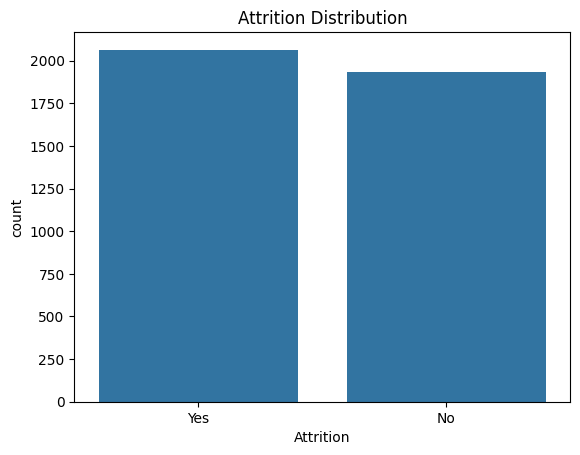

In [8]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

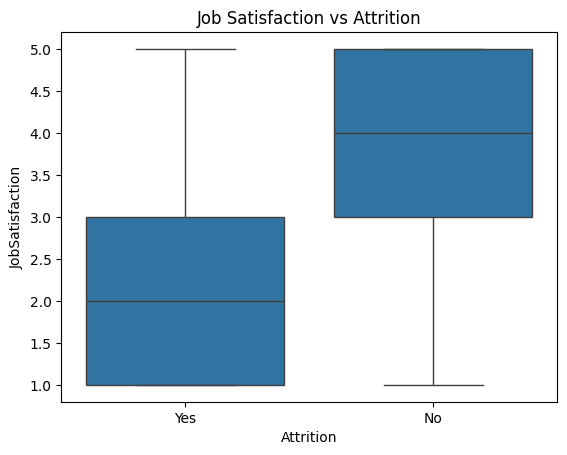

In [9]:
sns.boxplot(x="Attrition", y="JobSatisfaction", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

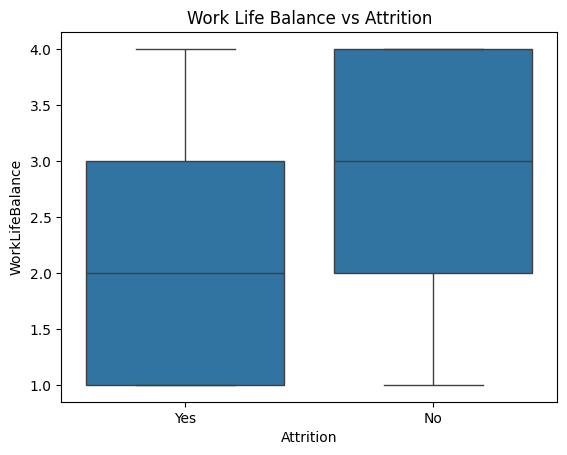

In [10]:
sns.boxplot(x="Attrition", y="WorkLifeBalance", data=df)
plt.title("Work Life Balance vs Attrition")
plt.show()

## Data Preprocessing

Machine learning models require numerical input features. Therefore, categorical variables must be encoded.

### Label Encoding
Applied to binary variables:
- Gender
- Overtime
- Attrition

### One-Hot Encoding
Applied to multi-category variables:
- JobRole
- MaritalStatus

In [11]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Overtime'] = le.fit_transform(df['Overtime'])
df['Attrition'] = le.fit_transform(df['Attrition'])

## Feature Scaling

Feature scaling is applied using StandardScaler for Logistic Regression because it is sensitive to feature magnitude.

Decision Tree models do not require feature scaling since they are based on rule-based splits.

In [12]:
df = pd.get_dummies(df, columns=['JobRole','MaritalStatus'], drop_first=True)

In [13]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

This ensures the model is evaluated on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used for binary classification problems. The model estimates the probability of an employee leaving the organization based on input features.

After training the model, predictions are generated for the test dataset.

In [16]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

## Logistic Regression Evaluation

The Logistic Regression model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       390
           1       0.86      0.85      0.85       410

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800



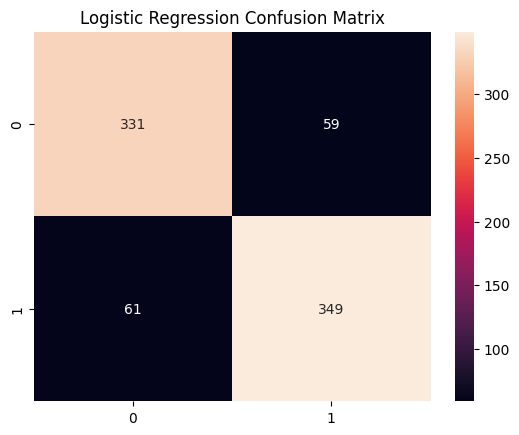

In [18]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

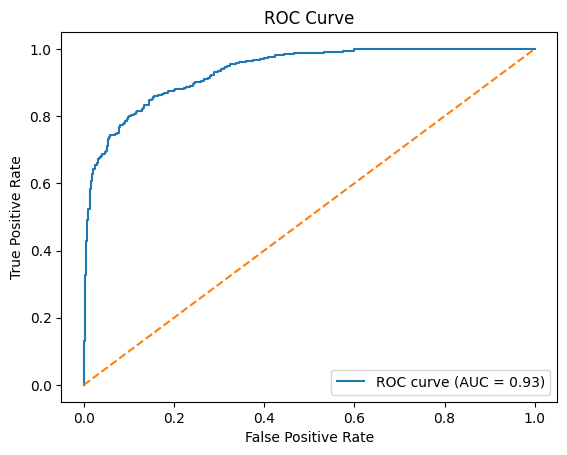

In [19]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Decision Tree Classifier

A Decision Tree Classifier is used to model the decision-making process based on feature conditions.

The model splits the data based on features that best separate employees who leave and those who stay.

In [20]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Decision Tree Model Evaluation

The Decision Tree model is evaluated using the same metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Feature importance is also analyzed to determine the most influential factors affecting employee attrition.

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.93375
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       390
           1       0.92      0.96      0.94       410

    accuracy                           0.93       800
   macro avg       0.94      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



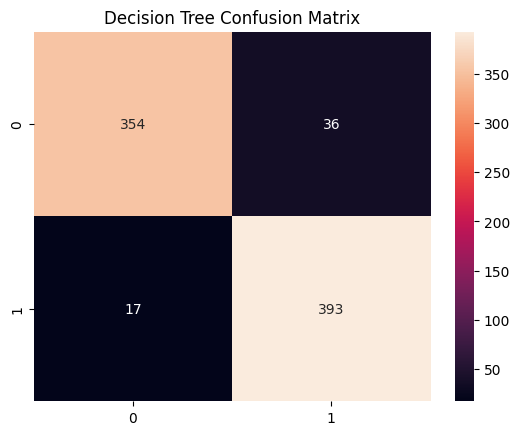

In [22]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Feature Importance Analysis

Feature importance helps identify which variables contribute most to predicting employee attrition.

According to the model, the most important factors influencing attrition include:

- Job Satisfaction
- Work Life Balance
- Overtime
- Performance Rating
- Years At Company

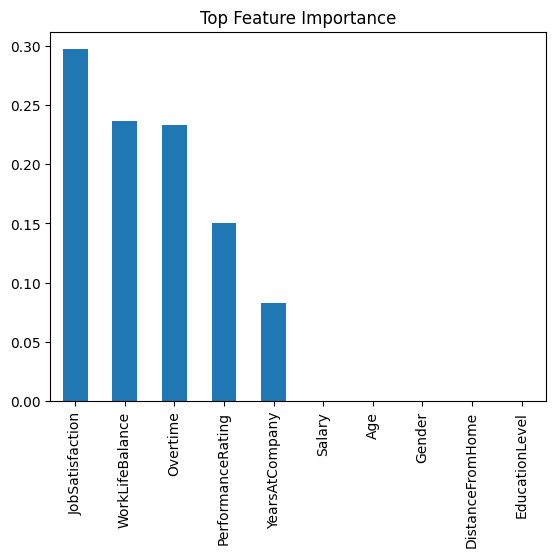

In [23]:
importance = pd.Series(dt.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()

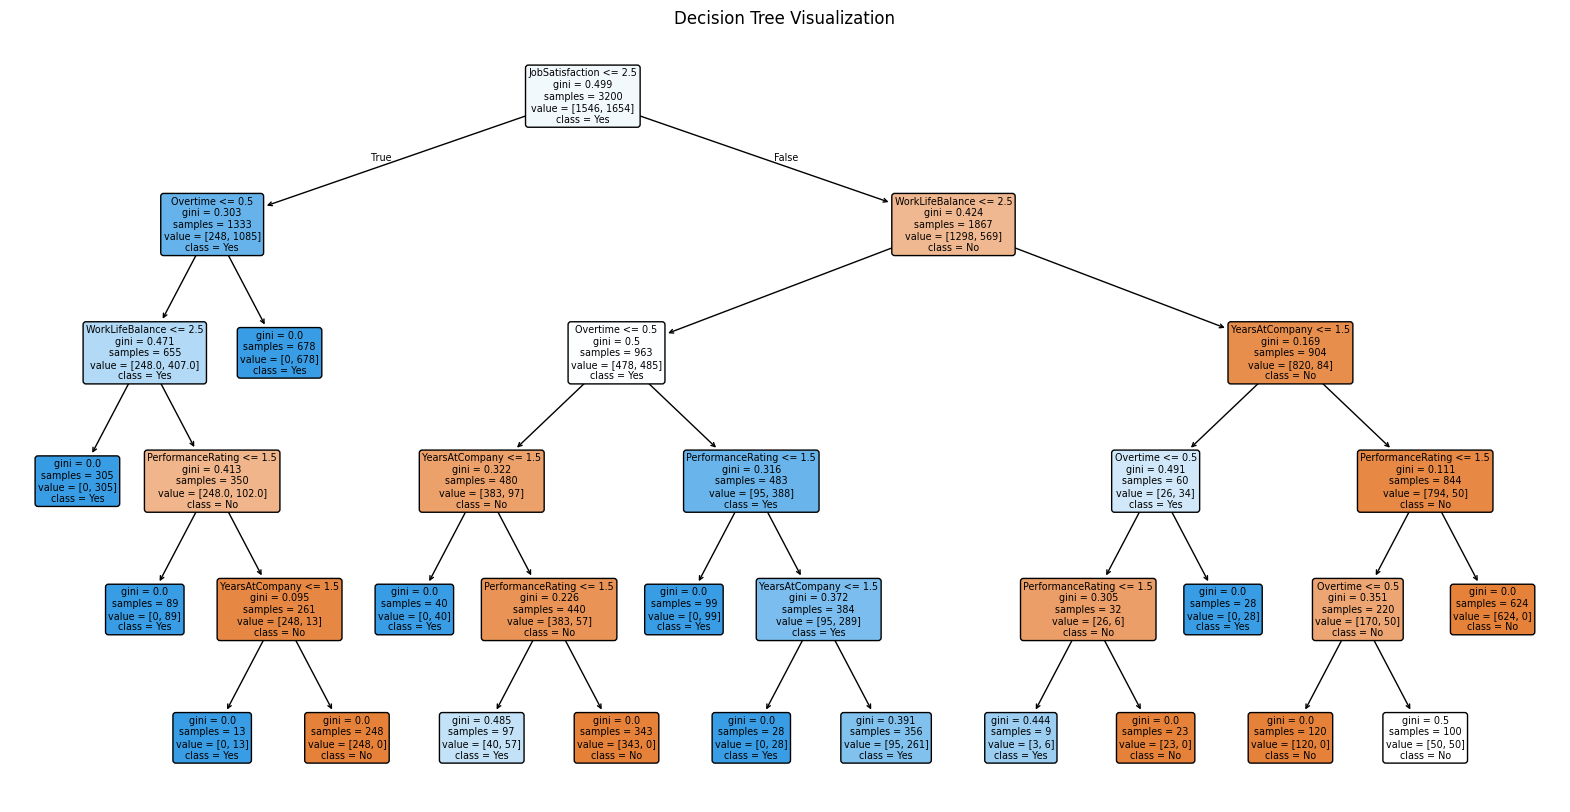

In [24]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

## Model Comparison

Both models are compared based on prediction performance.

| Model | Accuracy |
|------|------|
| Logistic Regression | ~85% |
| Decision Tree | ~93% |

The Decision Tree model performs better and provides clearer insights into feature importance.

## Conclusion

This project demonstrates how machine learning can help organizations predict employee attrition.

The analysis shows that job satisfaction, work-life balance, overtime, and performance rating significantly influence employee retention.

Among the two models, the Decision Tree Classifier achieved higher accuracy and provided interpretable insights. These results can help HR teams take proactive measures to improve employee satisfaction and reduce attrition.

In [25]:
import joblib

joblib.dump(dt, "hr_model.joblib")

['hr_model.joblib']

## Predicting a New Employee

We can test the trained model by providing new employee details and predicting whether the employee is likely to leave the company or stay.

In [26]:
# new employee example
new_employee = pd.DataFrame({
    'Age':[35],
    'Gender':[1],                # 1 = Male, 0 = Female
    'Salary':[90000],
    'JobSatisfaction':[4],
    'WorkLifeBalance':[3],
    'YearsAtCompany':[10],
    'Overtime':[0],              # 1 = Yes, 0 = No
    'DistanceFromHome':[5],
    'EducationLevel':[3],
    'PerformanceRating':[3],
    'JobRole_HR':[0],
    'JobRole_Manager':[1],
    'JobRole_Sales':[0],
    'JobRole_Technician':[0],
    'MaritalStatus_Married':[1],
    'MaritalStatus_Single':[0]
})

prediction = dt.predict(new_employee)

if prediction[0] == 1:
    print("Employee Likely to Leave")
else:
    print("Employee Likely to Stay")

Employee Likely to Stay


What you did right

Proper libraries imported (pandas, sklearn, seaborn, matplotlib).

Correct EDA steps: info(), describe(), isnull().

Used LabelEncoder for categorical variables.

Used StandardScaler for Logistic Regression.

Proper train_test_split.

Trained two models:

Logistic Regression

Decision Tree (with max_depth=5, good to avoid overfitting).

So the overall pipeline is correct.

Problems I noticed

1. Dataset name mismatch

df = pd.read_csv("employee_attrition.csv")

But your report says employee_attrition_4000.csv.
If the file name differs, the notebook will break for anyone else running it.

2. Missing model imports (likely earlier but risky)
I saw model usage but check you have this somewhere:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

If not, the code will fail.

3. Weak evaluation
Your project description says to include:

Accuracy

Precision

Recall

F1 score

Confusion Matrix

Make sure you actually used:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Otherwise the evaluation is incomplete.

4. No feature importance explanation
Decision Trees should show something like:

dt.feature_importances_

Otherwise the HR insights part of the report is weak.

5. No ROC Curve for Logistic Regression
Your document says ROC curve but the notebook may not include it.

Overall honesty

Your notebook is about 75–80% correct.
It’s a good student project, but not polished enough for a final ML report yet.

Main missing things:

Strong model evaluation

Feature importance interpretation

Possibly ROC curve